In [1]:
# ============================================
# CUSTOMER CHURN PREDICTION PROJECT
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import joblib


# Load dataset
df = pd.read_csv("customer_churn.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())


Dataset Shape: (900, 10)

Columns:
Index(['Names', 'Age', 'Total_Purchase', 'Account_Manager', 'Years',
       'Num_Sites', 'Onboard_date', 'Location', 'Company', 'Churn'],
      dtype='str')

First 5 Rows:
              Names   Age  Total_Purchase  Account_Manager  Years  Num_Sites  \
0  Cameron Williams  42.0        11066.80                0   7.22        8.0   
1     Kevin Mueller  41.0        11916.22                0   6.50       11.0   
2       Eric Lozano  38.0        12884.75                0   6.67       12.0   
3     Phillip White  42.0         8010.76                0   6.71       10.0   
4    Cynthia Norton  37.0         9191.58                0   5.56        9.0   

          Onboard_date                                           Location  \
0  2013-08-30 07:00:40      10265 Elizabeth Mission Barkerburgh, AK 89518   
1  2013-08-13 00:38:46  6157 Frank Gardens Suite 019 Carloshaven, RI 1...   
2  2016-06-29 06:20:07             1331 Keith Court Alyssahaven, DE 90114   
3  2

In [2]:
# ============================================
# 2. UNDERSTAND DATA
# ============================================

print("Dataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nStatistical Summary:")
print(df.describe())

print("\nChurn Distribution:")
print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Names            900 non-null    str    
 1   Age              900 non-null    float64
 2   Total_Purchase   900 non-null    float64
 3   Account_Manager  900 non-null    int64  
 4   Years            900 non-null    float64
 5   Num_Sites        900 non-null    float64
 6   Onboard_date     900 non-null    str    
 7   Location         900 non-null    str    
 8   Company          900 non-null    str    
 9   Churn            900 non-null    int64  
dtypes: float64(4), int64(2), str(4)
memory usage: 70.4 KB
None

Missing Values:
Names              0
Age                0
Total_Purchase     0
Account_Manager    0
Years              0
Num_Sites          0
Onboard_date       0
Location           0
Company            0
Churn              0
dtype: int64

Duplicate Rows:
0

Statistic

In [3]:
# ============================================
# 3. CLEAN DATA
# ============================================

# Remove duplicate rows
df = df.drop_duplicates().copy()

# Convert date column
df["Onboard_date"] = pd.to_datetime(
    df["Onboard_date"],
    errors="coerce"
)

# Check missing values after conversion
print("Missing Values After Cleaning:")
print(df.isnull().sum())

print("\nShape After Cleaning:", df.shape)

Missing Values After Cleaning:
Names              0
Age                0
Total_Purchase     0
Account_Manager    0
Years              0
Num_Sites          0
Onboard_date       0
Location           0
Company            0
Churn              0
dtype: int64

Shape After Cleaning: (900, 10)


In [4]:
# ============================================
# 4. FEATURE ENGINEERING
# ============================================

# Extract useful date features
df["Onboard_Year"] = df["Onboard_date"].dt.year
df["Onboard_Month"] = df["Onboard_date"].dt.month

# Remove columns that are not useful for prediction
# Names = individual identifier
# Location/Company = high-cardinality text fields
# Onboard_date = already converted into useful features

df = df.drop(
    columns=["Names", "Location", "Company", "Onboard_date"],
    errors="ignore"
)

print("Final Columns:")
print(df.columns)

print("\nSample Data:")
print(df.head())

Final Columns:
Index(['Age', 'Total_Purchase', 'Account_Manager', 'Years', 'Num_Sites',
       'Churn', 'Onboard_Year', 'Onboard_Month'],
      dtype='str')

Sample Data:
    Age  Total_Purchase  Account_Manager  Years  Num_Sites  Churn  \
0  42.0        11066.80                0   7.22        8.0      1   
1  41.0        11916.22                0   6.50       11.0      1   
2  38.0        12884.75                0   6.67       12.0      1   
3  42.0         8010.76                0   6.71       10.0      1   
4  37.0         9191.58                0   5.56        9.0      1   

   Onboard_Year  Onboard_Month  
0          2013              8  
1          2013              8  
2          2016              6  
3          2014              4  
4          2016              1  


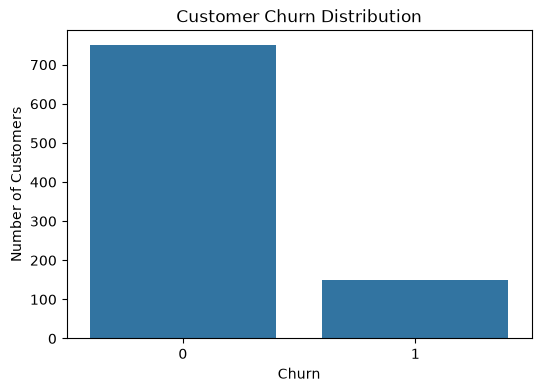

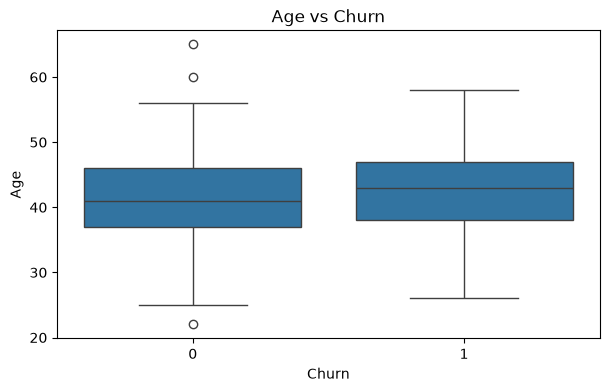

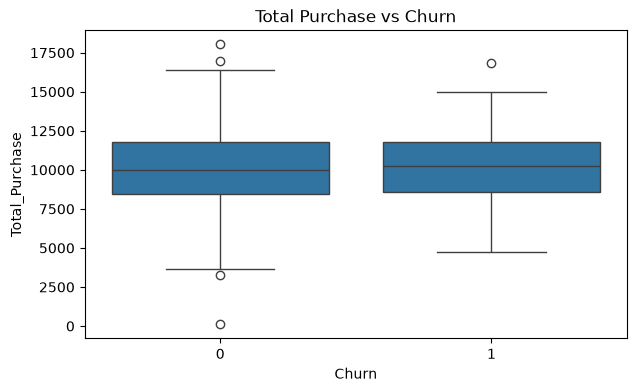

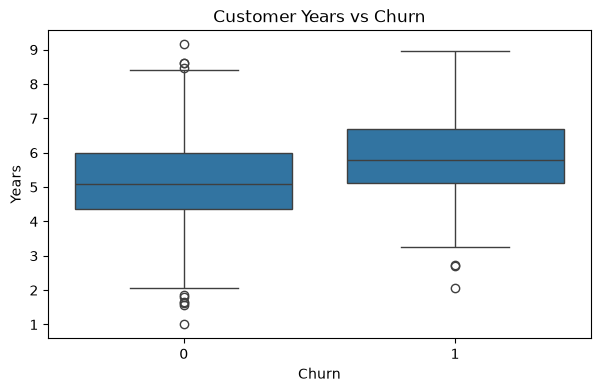

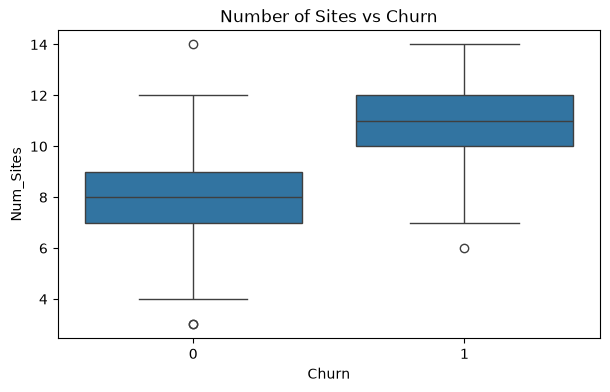

In [5]:
# ============================================
# 5. EXPLORATORY DATA ANALYSIS
# ============================================

# Churn distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()


# Churn vs Age
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="Churn", y="Age")
plt.title("Age vs Churn")
plt.show()


# Churn vs Total Purchase
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="Churn", y="Total_Purchase")
plt.title("Total Purchase vs Churn")
plt.show()


# Churn vs Years
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="Churn", y="Years")
plt.title("Customer Years vs Churn")
plt.show()


# Churn vs Number of Sites
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="Churn", y="Num_Sites")
plt.title("Number of Sites vs Churn")
plt.show()

In [6]:
# ============================================
# 6. PREPARE DATA
# ============================================

# Features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

print("\nX Shape:", X.shape)
print("y Shape:", y.shape)


# Identify numerical and categorical columns
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("\nNumerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)


# Numerical preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])


# Combine preprocessing
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Features:
Index(['Age', 'Total_Purchase', 'Account_Manager', 'Years', 'Num_Sites',
       'Onboard_Year', 'Onboard_Month'],
      dtype='str')

Target:
Churn

X Shape: (900, 7)
y Shape: (900,)

Numerical Features:
['Age', 'Total_Purchase', 'Account_Manager', 'Years', 'Num_Sites']

Categorical Features:
[]

Training Data: (720, 7)
Testing Data: (180, 7)


In [7]:
# ============================================
# 7. TRAIN MULTIPLE MODELS
# ============================================

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}


results = []

for model_name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, y_prob)
    })


results_df = pd.DataFrame(results)

print(results_df.sort_values(
    "ROC AUC",
    ascending=False
))

                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0  Logistic Regression  0.905556   0.809524  0.566667  0.666667  0.913333
1        Random Forest  0.861111   0.567568  0.700000  0.626866  0.877556
2    Gradient Boosting  0.888889   0.708333  0.566667  0.629630  0.870444


In [8]:
# ============================================
# 8. CROSS-VALIDATION + EVALUATION
# ============================================

# Select Random Forest as tuning candidate
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])


# Cross-validation
cv_scores = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("Cross-Validation ROC-AUC Scores:")
print(cv_scores)

print("\nMean CV ROC-AUC:",
      cv_scores.mean())


# Train model
rf_pipeline.fit(X_train, y_train)

# Predictions
y_pred = rf_pipeline.predict(X_test)
y_prob = rf_pipeline.predict_proba(X_test)[:, 1]


print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))


print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("Precision:",
      precision_score(y_test, y_pred, zero_division=0))

print("Recall:",
      recall_score(y_test, y_pred, zero_division=0))

print("F1 Score:",
      f1_score(y_test, y_pred, zero_division=0))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob))


Cross-Validation ROC-AUC Scores:
[0.90173611 0.82864583 0.90034722 0.91458333 0.84791667]

Mean CV ROC-AUC: 0.8786458333333333

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92       150
           1       0.60      0.70      0.65        30

    accuracy                           0.87       180
   macro avg       0.77      0.80      0.78       180
weighted avg       0.88      0.87      0.88       180

Accuracy: 0.8722222222222222
Precision: 0.6
Recall: 0.7
F1 Score: 0.6461538461538462
ROC-AUC: 0.8736666666666667


In [9]:
# ============================================
# 9. HYPERPARAMETER TUNING
# ============================================

param_grid = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}


grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)


grid_search.fit(X_train, y_train)


print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest CV ROC-AUC:")
print(grid_search.best_score_)


# Final tuned model
best_model = grid_search.best_estimator_


# Test predictions
y_pred_final = best_model.predict(X_test)
y_prob_final = best_model.predict_proba(X_test)[:, 1]


print("\nFINAL MODEL PERFORMANCE")

print("Accuracy:",
      accuracy_score(y_test, y_pred_final))

print("Precision:",
      precision_score(y_test, y_pred_final, zero_division=0))

print("Recall:",
      recall_score(y_test, y_pred_final, zero_division=0))

print("F1 Score:",
      f1_score(y_test, y_pred_final, zero_division=0))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_final))


print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_final,
    zero_division=0
))

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Parameters:
{'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best CV ROC-AUC:
0.8965972222222222

FINAL MODEL PERFORMANCE
Accuracy: 0.8555555555555555
Precision: 0.5526315789473685
Recall: 0.7
F1 Score: 0.6176470588235294
ROC-AUC: 0.8995555555555556

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.89      0.91       150
           1       0.55      0.70      0.62        30

    accuracy                           0.86       180
   macro avg       0.74      0.79      0.76       180
weighted avg       0.87      0.86      0.86       180



In [ ]:
# ============================================
# 10. FINAL VISUAL EVALUATION
# ============================================

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_final
)

plt.title("Customer Churn - Confusion Matrix")
plt.show()


# ROC Curve
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_final
)

plt.title("Customer Churn - ROC Curve")
plt.show()


In [10]:
# ============================================
# 11. FINAL PREDICTIONS
# ============================================

predictions = X_test.copy()

predictions["Actual_Churn"] = y_test.values
predictions["Predicted_Churn"] = y_pred_final
predictions["Churn_Probability"] = y_prob_final

print(predictions.head(10))

      Age  Total_Purchase  Account_Manager  Years  Num_Sites  Onboard_Year  \
390  35.0         8475.80                0   3.37       11.0          2013   
604  42.0        13081.64                0   4.66        9.0          2012   
796  48.0        10746.37                1   4.22        8.0          2006   
249  43.0        11197.42                1   3.48        9.0          2009   
706  42.0        10807.46                1   6.74        7.0          2007   
810  41.0         8427.12                0   4.37        6.0          2012   
202  45.0        12783.21                1   4.47       10.0          2015   
111  36.0         6330.43                1   5.43        7.0          2010   
278  38.0        12893.47                1   5.69        5.0          2012   
882  49.0         8523.04                1   4.15        5.0          2014   

     Onboard_Month  Actual_Churn  Predicted_Churn  Churn_Probability  
390              9             0                0           0.354392  

In [11]:
# ============================================
# 12. SAVE MODEL
# ============================================

joblib.dump(
    best_model,
    "customer_churn_model.pkl"
)

print("Model saved successfully!")
print("File: customer_churn_model.pkl")

Model saved successfully!
File: customer_churn_model.pkl
